In [ ]:
!pip uninstall -y mediapipe protobuf tensorflow
!pip install mediapipe==0.10.13 protobuf==4.25.3

Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 23.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-datastore 2.25.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-bigquery-connection 1.22.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-translate 3.27.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-language 2.21.0 requires protobuf<8.0.0,>=4.25.8, bu

In [ ]:
import mediapipe as mp

print(mp.__version__)
print(mp.solutions.pose)

0.10.13
<module 'mediapipe.python.solutions.pose' from '/usr/local/lib/python3.12/dist-packages/mediapipe/python/solutions/pose.py'>


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install opencv-python tqdm pandas numpy matplotlib

In [ ]:
import os

zip_path = "/content/drive/MyDrive/AI_Personal_Stylist/data/train.zip"

print("File Exists:", os.path.exists(zip_path))

File Exists: True


In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as z:
    files = z.namelist()

print("Total files:", len(files))

print("\nFirst 30 files:\n")

for f in files[:30]:
    print(f)

Total files: 383925

First 30 files:

train/
train/annos/
train/annos/062045.json
train/annos/187399.json
train/annos/070717.json
train/annos/144302.json
train/annos/051290.json
train/annos/105740.json
train/annos/043233.json
train/annos/098116.json
train/annos/087629.json
train/annos/112492.json
train/annos/013769.json
train/annos/005952.json
train/annos/108545.json
train/annos/175586.json
train/annos/090461.json
train/annos/186858.json
train/annos/177614.json
train/annos/051749.json
train/annos/039260.json
train/annos/185750.json
train/annos/100950.json
train/annos/180626.json
train/annos/037571.json
train/annos/139407.json
train/annos/115462.json
train/annos/127488.json
train/annos/108780.json
train/annos/164003.json


In [ ]:
image_files = [f for f in files if "train/image/" in f]

print("Number of images:", len(image_files))

print("\nFirst 10 images:")

for img in image_files[:10]:
    print(img)

Number of images: 191962

First 10 images:
train/image/
train/image/168633.jpg
train/image/168475.jpg
train/image/039509.jpg
train/image/089661.jpg
train/image/065242.jpg
train/image/065416.jpg
train/image/064783.jpg
train/image/157368.jpg
train/image/118323.jpg


In [ ]:
import zipfile
import random
import os
from tqdm import tqdm

zip_path = "/content/drive/MyDrive/AI_Personal_Stylist/data/train.zip"
output_dir = "/content/deepfashion_subset"

os.makedirs(output_dir, exist_ok=True)

random.seed(42)

with zipfile.ZipFile(zip_path, "r") as z:

    all_files = z.namelist()

    image_files = [
        f for f in all_files
        if f.startswith("train/image/")
        and f.endswith(".jpg")
    ]

    print("Total Images:", len(image_files))

    sample_size = 5000

    selected = random.sample(image_files, sample_size)

    files_to_extract = []

    for img in selected:

        files_to_extract.append(img)

        json_path = img.replace("train/image/", "train/annos/")
        json_path = json_path.replace(".jpg", ".json")

        if json_path in all_files:
            files_to_extract.append(json_path)

    print("Files to Extract:", len(files_to_extract))

    for file in tqdm(files_to_extract):
        z.extract(file, output_dir)

print("Extraction Complete!")

Total Images: 191961
Files to Extract: 10000


100%|██████████| 10000/10000 [03:18<00:00, 50.41it/s]

Extraction Complete!


In [ ]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=2,
    enable_segmentation=False,
    min_detection_confidence=0.5
)

In [ ]:
image_dir = "/content/deepfashion_subset/train/image"

image_paths = [
    os.path.join(image_dir, img)
    for img in os.listdir(image_dir)
    if img.endswith(".jpg")
]

print("Total Images:", len(image_paths))

Total Images: 5000


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


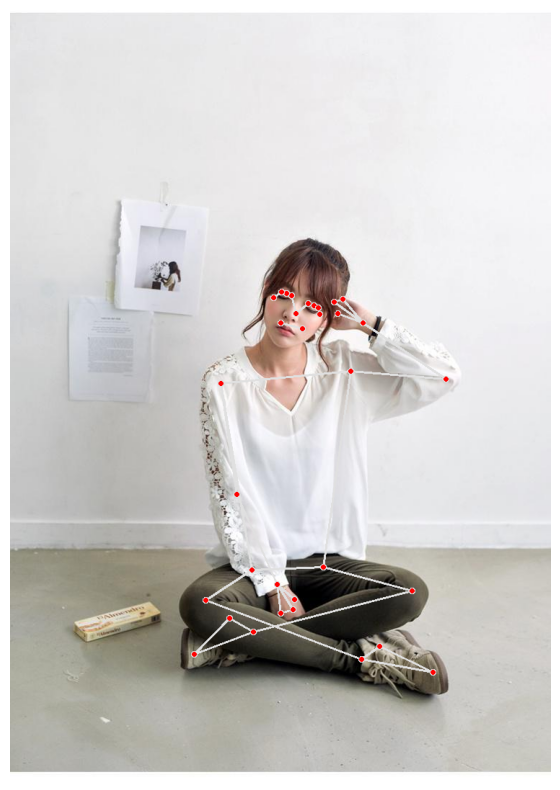

In [ ]:
image = cv2.imread(image_paths[0])

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

result = pose.process(rgb)

annotated = image.copy()

if result.pose_landmarks:

    mp_drawing.draw_landmarks(
        annotated,
        result.pose_landmarks,
        mp_pose.POSE_CONNECTIONS
    )

plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
good_images = []

for path in tqdm(image_paths):

    img = cv2.imread(path)

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    result = pose.process(rgb)

    if result.pose_landmarks:

        good_images.append(path)

print("Successful detections:", len(good_images))

100%|██████████| 5000/5000 [10:42<00:00,  7.79it/s]

Successful detections: 3596


In [ ]:
from tqdm import tqdm
import cv2
import pandas as pd

filtered_images = []
quality_scores = []

for path in tqdm(good_images):

    image = cv2.imread(path)

    if image is None:
        continue

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    result = pose.process(rgb)

    if not result.pose_landmarks:
        continue

    lm = result.pose_landmarks.landmark

    score = 0

    # Shoulders and hips (2 points each)
    for idx in [11, 12, 23, 24]:
        if lm[idx].visibility > 0.7:
            score += 2

    # Knees and ankles (1 point each)
    for idx in [25, 26, 27, 28]:
        if lm[idx].visibility > 0.5:
            score += 1

    # Nose (1 point)
    if lm[0].visibility > 0.5:
        score += 1

    if score >= 9:
        filtered_images.append(path)
        quality_scores.append(score)

quality_df = pd.DataFrame({
    "image_path": filtered_images,
    "quality_score": quality_scores
})

print(f"Filtered Images: {len(filtered_images)}")
quality_df.head()

100%|██████████| 3596/3596 [09:42<00:00,  6.17it/s]


Filtered Images: 3345


,image_path,quality_score
0,/content/deepfashion_subset/train/image/000242...,13
1,/content/deepfashion_subset/train/image/127774...,9
2,/content/deepfashion_subset/train/image/059415...,10
3,/content/deepfashion_subset/train/image/080655...,13
4,/content/deepfashion_subset/train/image/091255...,9


In [ ]:
import os
import cv2
import pandas as pd
from tqdm import tqdm

rows = []

for path in tqdm(filtered_images):

    image = cv2.imread(path)

    if image is None:
        continue

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    result = pose.process(rgb)

    if not result.pose_landmarks:
        continue

    row = {
        "image_name": os.path.basename(path)
    }

    landmarks = result.pose_landmarks.landmark

    for i, lm in enumerate(landmarks):

        row[f"x_{i}"] = lm.x
        row[f"y_{i}"] = lm.y
        row[f"z_{i}"] = lm.z
        row[f"v_{i}"] = lm.visibility

    rows.append(row)

landmarks_df = pd.DataFrame(rows)

print("Shape:", landmarks_df.shape)

landmarks_df.head()

  0%|          | 0/3345 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
100%|██████████| 3345/3345 [09:03<00:00,  6.15it/s]


Shape: (3345, 133)


,image_name,x_0,y_0,z_0,v_0,x_1,y_1,z_1,v_1,x_2,...,z_30,v_30,x_31,y_31,z_31,v_31,x_32,y_32,z_32,v_32
0,000242.jpg,0.528114,0.394190,-0.385114,0.999902,0.551572,0.380946,-0.349805,0.999841,0.562067,...,-0.597790,0.885452,0.340820,0.837020,-0.464781,0.881047,0.781626,0.860475,-0.732348,0.916506
1,127774.jpg,0.562119,0.258463,-1.073987,0.999801,0.601826,0.235643,-1.017335,0.999352,0.621495,...,0.283673,0.038120,0.604510,1.331599,0.801270,0.011623,0.428979,1.307187,0.014324,0.023548
2,059415.jpg,0.631948,0.357898,-0.693593,0.999971,0.642627,0.339306,-0.669784,0.999931,0.651986,...,0.428700,0.110689,0.686511,1.069409,0.030404,0.132786,0.631896,1.054492,0.240767,0.128118
3,080655.jpg,0.472713,0.108839,-0.398280,0.999920,0.486893,0.090239,-0.358356,0.999811,0.496536,...,0.070961,0.353042,0.606845,0.952268,0.051820,0.748885,0.554261,0.964541,-0.179616,0.818753
4,091255.jpg,0.328489,0.194002,-0.643718,0.999739,0.334360,0.149552,-0.604800,0.998997,0.350069,...,-0.039389,0.004257,0.730577,1.622418,0.058257,0.001938,0.616331,1.635101,-0.230562,0.002015


In [ ]:
output_csv = "/content/drive/MyDrive/AI_Personal_Stylist/datasets/landmarks.csv"

os.makedirs(os.path.dirname(output_csv), exist_ok=True)

landmarks_df.to_csv(output_csv, index=False)

print("Saved:", output_csv)

Saved: /content/drive/MyDrive/AI_Personal_Stylist/datasets/landmarks.csv
